In [1]:
import pandas as pd

In [3]:
import matplotlib.pyplot as ptl

In [4]:
import seaborn as sb

In [7]:
#Carga del conjunto de datos
df = pd.read_csv("netflix_titles.csv")

In [10]:
#Muestra las primeras 5 filas
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
#Muestra el numero de filas y columnas (dimensiones) del DataFrame
df.shape

(8807, 12)

In [12]:
#Muestra el nombre de todas las columnas del dataframe
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [13]:
#Muestra los tipos de datos asignados a cada columna
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [14]:
#Cuenta la cantidad de valores nulos o vacios por cada columna
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [15]:
#Calcula el porcentaje de valores nulos por columna
(df.isnull().sum() / len(df)) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [16]:
# Cuenta el total de filas duplicadas en el dataset
df.duplicated().sum()

np.int64(0)

In [20]:
 # 1. Transformación: Rellenamos valores nulos en columnas categóricas con "Unknown"
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
# 2. Eliminación: Borramos las pocas filas donde faltan datos críticos y escasos
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

In [21]:
#Calcula el porcentaje de valores nulos por columna despues de transformar y eliminar datos
(df.isnull().sum() / len(df)) * 100

show_id         0.0
type            0.0
title           0.0
director        0.0
cast            0.0
country         0.0
date_added      0.0
release_year    0.0
rating          0.0
duration        0.0
listed_in       0.0
description     0.0
dtype: float64

C:\Users\pepit\AppData\Local\Temp\ipykernel_10480\2095238871.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=df, x='type', palette='viridis')


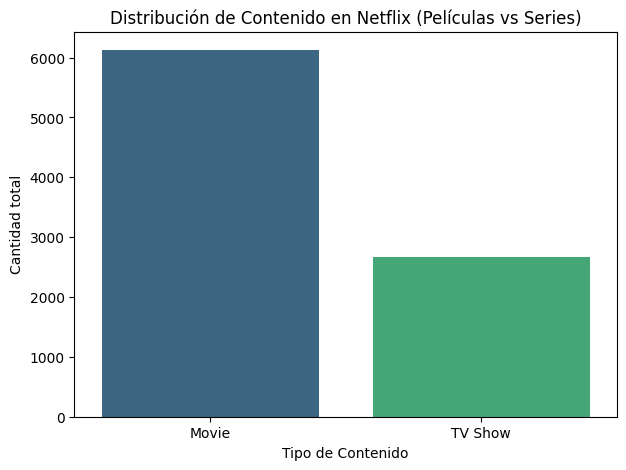

In [24]:
# Configuración del gráfico de barras para el tipo de contenido
# Buscamos comparar la cantidad de contenido total entre Peliculas y Show de television
ptl.figure(figsize=(7, 5))
sb.countplot(data=df, x='type', palette='viridis')
ptl.title('Distribución de Contenido en Netflix (Películas vs Series)')
ptl.xlabel('Tipo de Contenido')
ptl.ylabel('Cantidad total')
ptl.show()

C:\Users\pepit\AppData\Local\Temp\ipykernel_10480\1781199206.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=top_countries.values, y=top_countries.index,


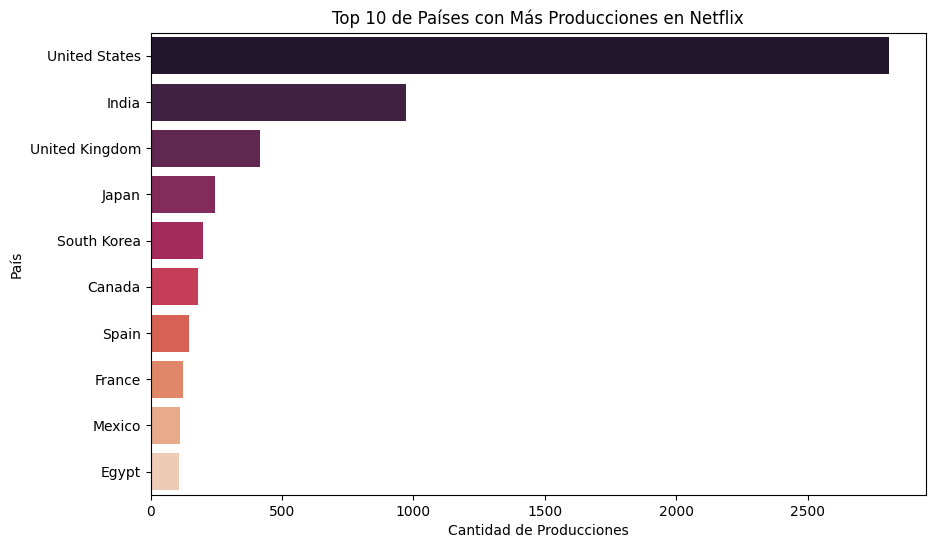

In [25]:
 # Filtramos 'Unknown' y calculamos el top 10 de países creadores de contenido
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
ptl.figure(figsize=(10, 6))
sb.barplot(x=top_countries.values, y=top_countries.index,
palette='rocket')
ptl.title('Top 10 de Países con Más Producciones en Netflix')
ptl.xlabel('Cantidad de Producciones')
ptl.ylabel('País')
ptl.show()

C:\Users\pepit\AppData\Local\Temp\ipykernel_10480\4083176870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=top_ratings.index, y=top_ratings.values, palette='mako')


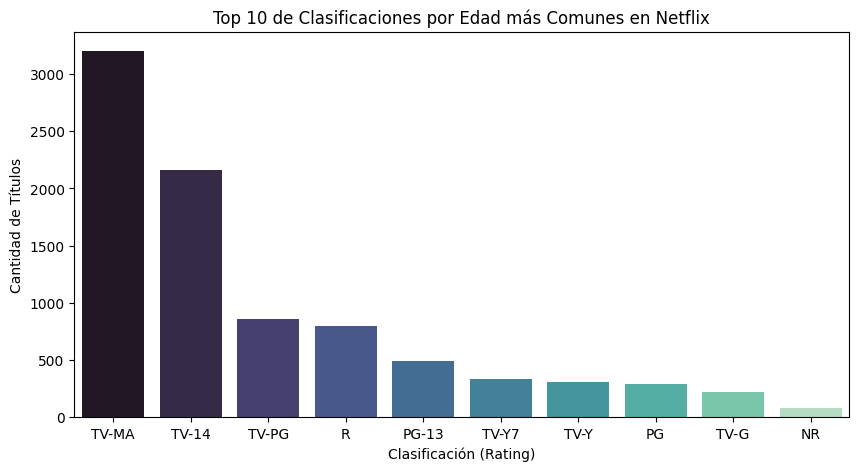

In [26]:
# Obtenemos las 10 clasificaciones de edad más recurrentes
top_ratings = df['rating'].value_counts().head(10)

ptl.figure(figsize=(10, 5))
sb.barplot(x=top_ratings.index, y=top_ratings.values, palette='mako')
ptl.title('Top 10 de Clasificaciones por Edad más Comunes en Netflix')
ptl.xlabel('Clasificación (Rating)')
ptl.ylabel('Cantidad de Títulos')
ptl.show()

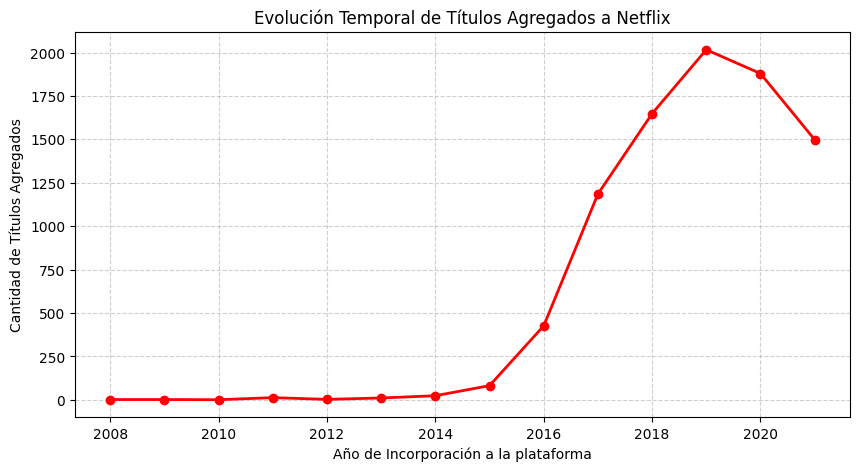

In [27]:
  # Extraemos de forma segura el año en que el título fue agregado a Netflix
df['year_added'] = pd.to_datetime(df['date_added'].str.strip(),
errors='coerce').dt.year
added_by_year = df['year_added'].value_counts().sort_index()

ptl.figure(figsize=(10, 5))
ptl.plot(added_by_year.index, added_by_year.values, marker='o',
color='red', linewidth=2)
ptl.title('Evolución Temporal de Títulos Agregados a Netflix')
ptl.xlabel('Año de Incorporación a la plataforma')
ptl.ylabel('Cantidad de Títulos Agregados')
ptl.grid(True, linestyle='--', alpha=0.6)
ptl.show()

  1. **Preferencia por Largometrajes (Películas vs. Series):**
       A pesar del gran auge publicitario que tienen las series de televisión
  en los últimos años, el catálogo histórico de Netflix está dominado de
  forma contundente por **Películas (Movies)**. Esto demuestra que la
  estrategia de adquisición y licenciamiento tradicional de Netflix sigue
  teniendo su pilar principal en los largometrajes de una sola entrega.

    2. **Dominancia del Eje Hollywood-Bollywood (Top Países):**
       **Estados Unidos e India** lideran de manera indiscutible la creación
  de contenido dentro de la plataforma. Esto refleja que el núcleo de la
  biblioteca de Netflix está fuertemente centralizado en dos de las
  industrias cinematográficas más gigantescas del mundo, requiriendo un mayor
  esfuerzo si la plataforma busca diversificar hacia mercados más locales.

    3. **Público Objetivo Adulto y Juvenil (Ratings):**
       Las categorías de clasificación de edad dominantes son **TV-MA
  (público maduro/adulto)** y **TV-14 (jóvenes mayores de 14 años)**. Netflix
  no se posiciona como una plataforma puramente infantil o familiar (como
  Disney+), sino que concentra la gran mayoría de su inversión en contenidos
  con tramas complejas, acción, drama o comedia dirigidos a audiencias
  maduras.

    4. **El "Boom" de Contenido (Evolución Temporal):**
       El gráfico de evolución temporal revela un crecimiento exponencial en
  la adición de títulos que alcanzó su pico máximo entre **2018 y 2020**
  (coincidiendo con su expansión masiva y la pandemia global). Posterior a
  2020, se observa un cambio de estrategia hacia la estabilización de
  catálogo, donde Netflix parece apostar más por la calidad y producciones
  originales que por volumen masivo de licencias externas.

1. **Descentralizar la Producción e Invertir en Mercados Emergentes:**
       Dado el abrumador dominio de contenidos producidos en EE. UU. e India,
  Netflix debe acelerar y diversificar sus inversiones en producciones
  originales locales de mercados emergentes clave (como Latinoamérica, Europa
  del Este y Corea del Sur). El éxito global de series como *El Juego del
  Calamar* demuestra que el contenido local de alta calidad no solo capta
  suscriptores regionales, sino que se convierte en un activo de exportación
  global de bajo costo.

    2. **Migrar Presupuesto de Películas hacia Series de Alta Retención:**
       Aunque el catálogo histórico está dominado cuantitativamente por
  películas, las series de televisión garantizan un mayor "tiempo de
  pantalla" de los usuarios en la plataforma y disminuyen las tasas de
  cancelación de suscripción (Churn Rate). Se recomienda reestructurar el
  presupuesto para priorizar series por episodios y miniseries exclusivas que
  mantengan a la audiencia enganchada mes a mes, en lugar de largometrajes
  únicos que se consumen en una sola sesión.

    3. **Consolidar el Segmento TV-MA y Crear Marcas Satélite Familiares:**
       Sabiendo que su fuerte es el público adulto (TV-MA y TV-14), Netflix
  debe consolidar esta posición produciendo dramas, thrillers y documentales
  premium de alta fidelidad para diferenciarse de su competidor más fuerte en
  el sector familiar, Disney+. Sin embargo, para no perder el mercado del
  hogar completo, debería crear alianzas de co-branding exclusivas con marcas
  de animación infantil para robustecer su oferta sin diluir la identidad de
  su marca principal